### Spatial analysis of malignant cells from 2 regions on the same sample

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import scanpy as sc
import squidpy as sq

import os

/homevol/huemail/miniconda3/envs/xenium.squidpy/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
os.getcwd()

'/homevol/huemail/G000428_MaiLa/analysis/Xenium480'

In [79]:
# Set working directory to save files
new_directory = "/homevol/huemail/G000428_MaiLa/Xenium_repeated_n8_probev2/adata_objects_Aug25"
os.chdir(new_directory)

In [80]:
adata = sc.read_h5ad("MH097_setseed_v2.h5ad") 

In [5]:
adata

AnnData object with n_obs × n_vars = 194626 × 480
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'n_counts', 'leiden_1.0', 'leiden_1.4', 'anno', 'predicted_cell_type_threshold', 'leiden_1.6', 'leiden_1.8', 'leiden_2.0', 'broad_cell_class', 'sample', 'Malignant cells_score', 'Ductal MUC5B_score', 'Ductal_score', 'Endocrine_score', 'FDCs_score', 'FRCs_score', 'TRCs_score', 'LECs_score', 'Endothelial_score', 'SMCs_score', 'Pericytes_score', 'Schwann_score', 'Neurons_score', 'CAFs_MYO_score', 'CAFs_CXCL14_score', 'CAFs_NRT_score', 'NK_score', 'CD4 T cells_score',

In [6]:
# Subset data to region of interest, remove areas that are not so great - the bottom right was not imaged well
# Create a boolean mask based on spatial coordinates - PanIN as annotated by pathologist, but transcriptionally expressing malignant cell identity 
x_min = 2200
x_max = 5000
y_min = 1000
y_max = 4000

criteria = (
    (adata.obs['x_centroid'] >= x_min) & (adata.obs['x_centroid'] <= x_max) &
    (adata.obs['y_centroid'] >= y_min) & (adata.obs['y_centroid'] <= y_max)
)

# Subset the AnnData object based on the spatial criteria
subset_1 = adata[criteria, :]

In [7]:
# Subset data to region of interest, remove areas that are not so great - the bottom right was not imaged well
# Create a boolean mask based on spatial coordinates - this region select malignant cells surrounded by SPP1+ TAMs, OLR1+ TAMs and myofibroblasts
x_min = 8200
x_max = 9500
y_min = 3500
y_max = 4500

criteria = (
    (adata.obs['x_centroid'] >= x_min) & (adata.obs['x_centroid'] <= x_max) &
    (adata.obs['y_centroid'] >= y_min) & (adata.obs['y_centroid'] <= y_max)
)

# Subset the AnnData object based on the spatial criteria
subset_2 = adata[criteria, :]

In [15]:
malig_PanIN.X[:25,5:].toarray()

array([[ 0.,  0.,  8., ...,  0.,  0.,  0.],
       [ 0.,  0.,  4., ...,  0.,  0.,  0.],
       [ 0.,  6.,  8., ...,  0.,  0.,  0.],
       ...,
       [ 0.,  7., 10., ...,  0.,  0.,  1.],
       [ 0.,  1.,  5., ...,  0.,  0.,  0.],
       [ 0.,  3., 13., ...,  0.,  0.,  1.]], dtype=float32)

In [16]:
malig_only.X[:25,5:].toarray()

array([[ 0.,  2.,  3., ...,  0.,  0.,  1.],
       [ 0.,  0.,  7., ...,  0.,  0.,  0.],
       [ 0.,  8.,  8., ...,  0.,  0.,  0.],
       ...,
       [ 0.,  1.,  2., ...,  0.,  0.,  0.],
       [ 0.,  4.,  3., ...,  0.,  0.,  0.],
       [ 0.,  9., 44., ...,  0.,  0.,  2.]], dtype=float32)

In [10]:
malig_PanIN = subset_1[subset_1.obs['cell_class_threshold']=="Malignant cells"].copy()
malig_only = subset_2[subset_2.obs['cell_class_threshold']=="Malignant cells"].copy()

In [13]:
# Ensure X = raw counts before renalysing 
malig_PanIN.X = malig_PanIN.layers['counts'].copy()
malig_only.X = malig_only.layers['counts'].copy() 

In [22]:
# Adding metadata to the adata before combinding them
malig_PanIN.obs["Region"] = "PanIN"
malig_only.obs["Region"] = "PDAC"

import anndata as ad
merged = ad.concat([malig_PanIN, malig_only], merge="same")

In [23]:
merged.obs['anno'].cat.categories

Index(['CAFs_MYO', 'Ductal', 'Ductal_MUC6_REG1A', 'Endothelial',
       'Malignant cells', 'Neutrophils', 'Plasma', 'TAMs_OLR1', 'TAMs_SPP1',
       'vSMCs'],
      dtype='object')

In [24]:
merged = merged[~merged.obs['anno'].isin(['CAFs_MYO', 'Ductal', 'Endothelial',
       'Neutrophils', 'Plasma', 'TAMs_OLR1', 'TAMs_SPP1',
       'vSMCs'])].copy() # filter to ensure only malignant cells being tested

In [25]:
# CALCULATING QC METRICS
sc.pp.calculate_qc_metrics(merged , percent_top=(10, 20, 50, 150), inplace=True)

In [26]:
cprobes = (
    merged.obs["control_probe_counts"].sum() / merged.obs["total_counts"].sum() * 100
)
cwords = (
    merged.obs["control_codeword_counts"].sum() / merged.obs["total_counts"].sum() * 100
)
print(f"Negative DNA probe count % : {cprobes}")
print(f"Negative decoding count % : {cwords}")

Negative DNA probe count % : 0.002365816786416426
Negative decoding count % : 0.004909069831814085


In [28]:
# Preprocessing
merged.layers["counts"] = merged.X.copy()
sc.pp.normalize_total(merged, inplace=True)
sc.pp.log1p(merged)

# scale the data for visualisation step later
merged.layers['scaled'] = sc.pp.scale(merged, copy=True).X

# Dimentionality reduction
sc.pp.pca(merged, n_comps = 50, random_state=36)
sc.pp.neighbors(merged, n_neighbors = 30, random_state=36)
sc.tl.umap(merged, random_state=36)

In [29]:
# Clustering by leiden, using different resolutions
resolutions = [0.5, 1.0]

for resolution in resolutions:
    key_added = f"leiden_{resolution}"
    sc.tl.leiden(merged, resolution=resolution, key_added=key_added, random_state=36)

In [64]:
merged.write_h5ad("MH097_malignant_SUBSET_PanIN_DE_rerun.h5ad") # Saving results

/homevol/huemail/.local/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1216: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/homevol/huemail/.local/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:391: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/homevol/huemail/.local/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1216: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/homevol/huemail/.l

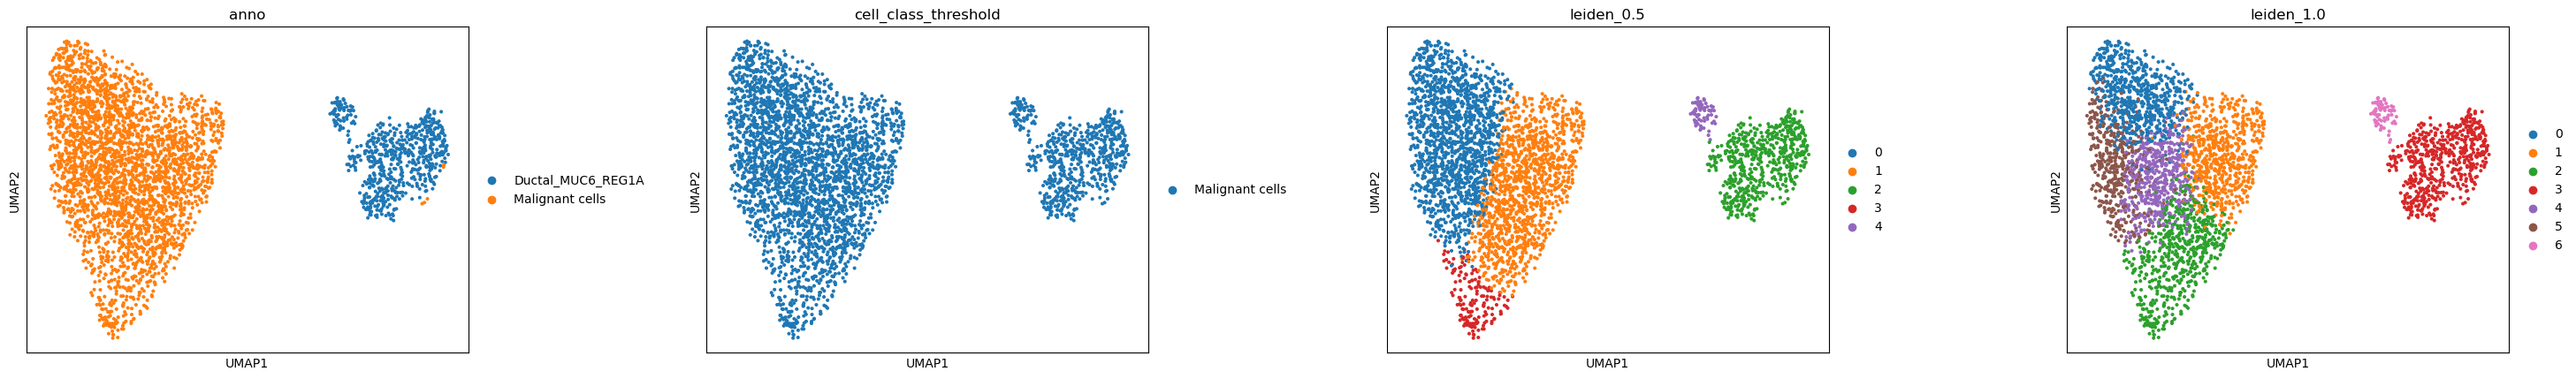

In [33]:
sc.pl.umap(merged, color=['anno','cell_class_threshold','leiden_0.5','leiden_1.0'], wspace = 0.4) #,'

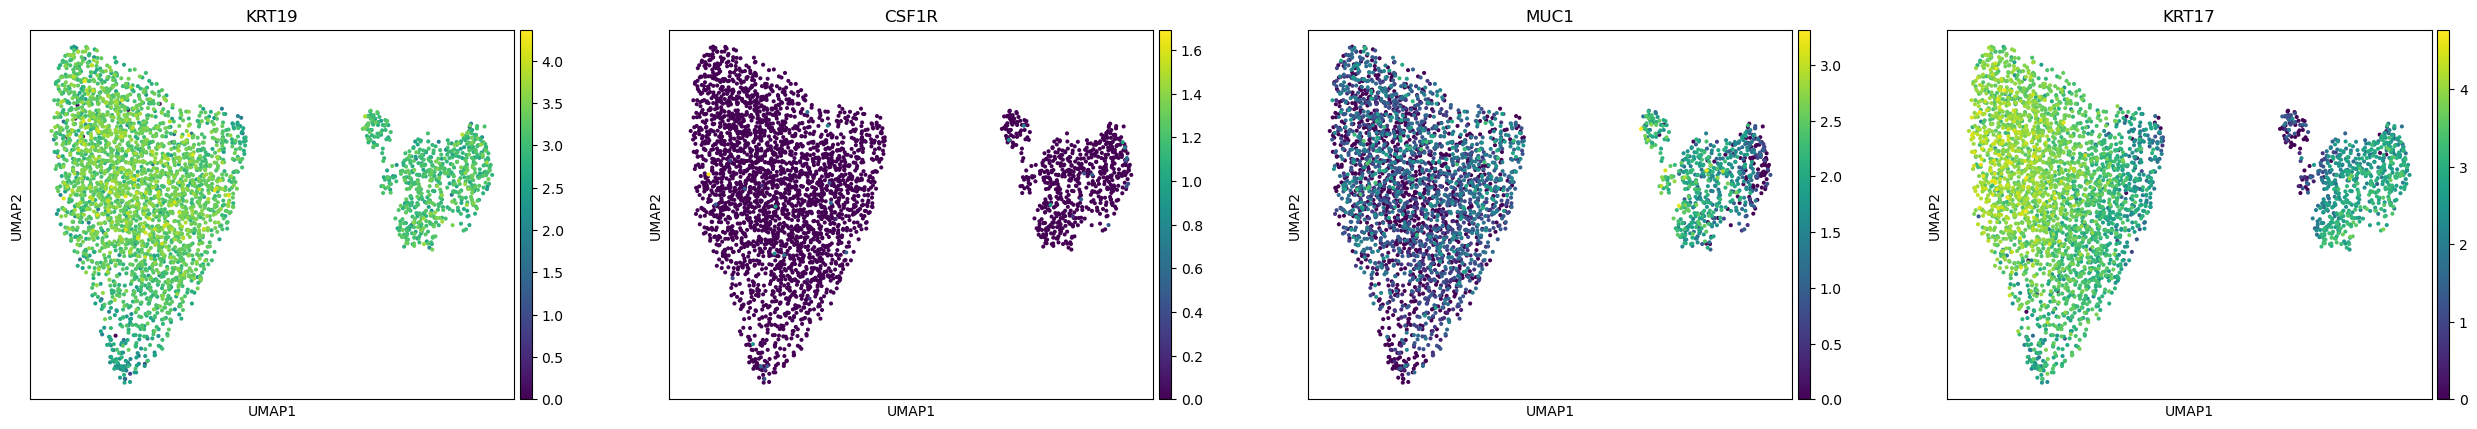

In [61]:
sc.pl.umap(merged, color=['KRT19','CSF1R','MUC1','KRT17'], wspace = 0.2,
          save='Malignant_cell_identity.pdf') #,'

/homevol/huemail/miniconda3/envs/xenium.squidpy/lib/python3.9/site-packages/numpy/core/fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


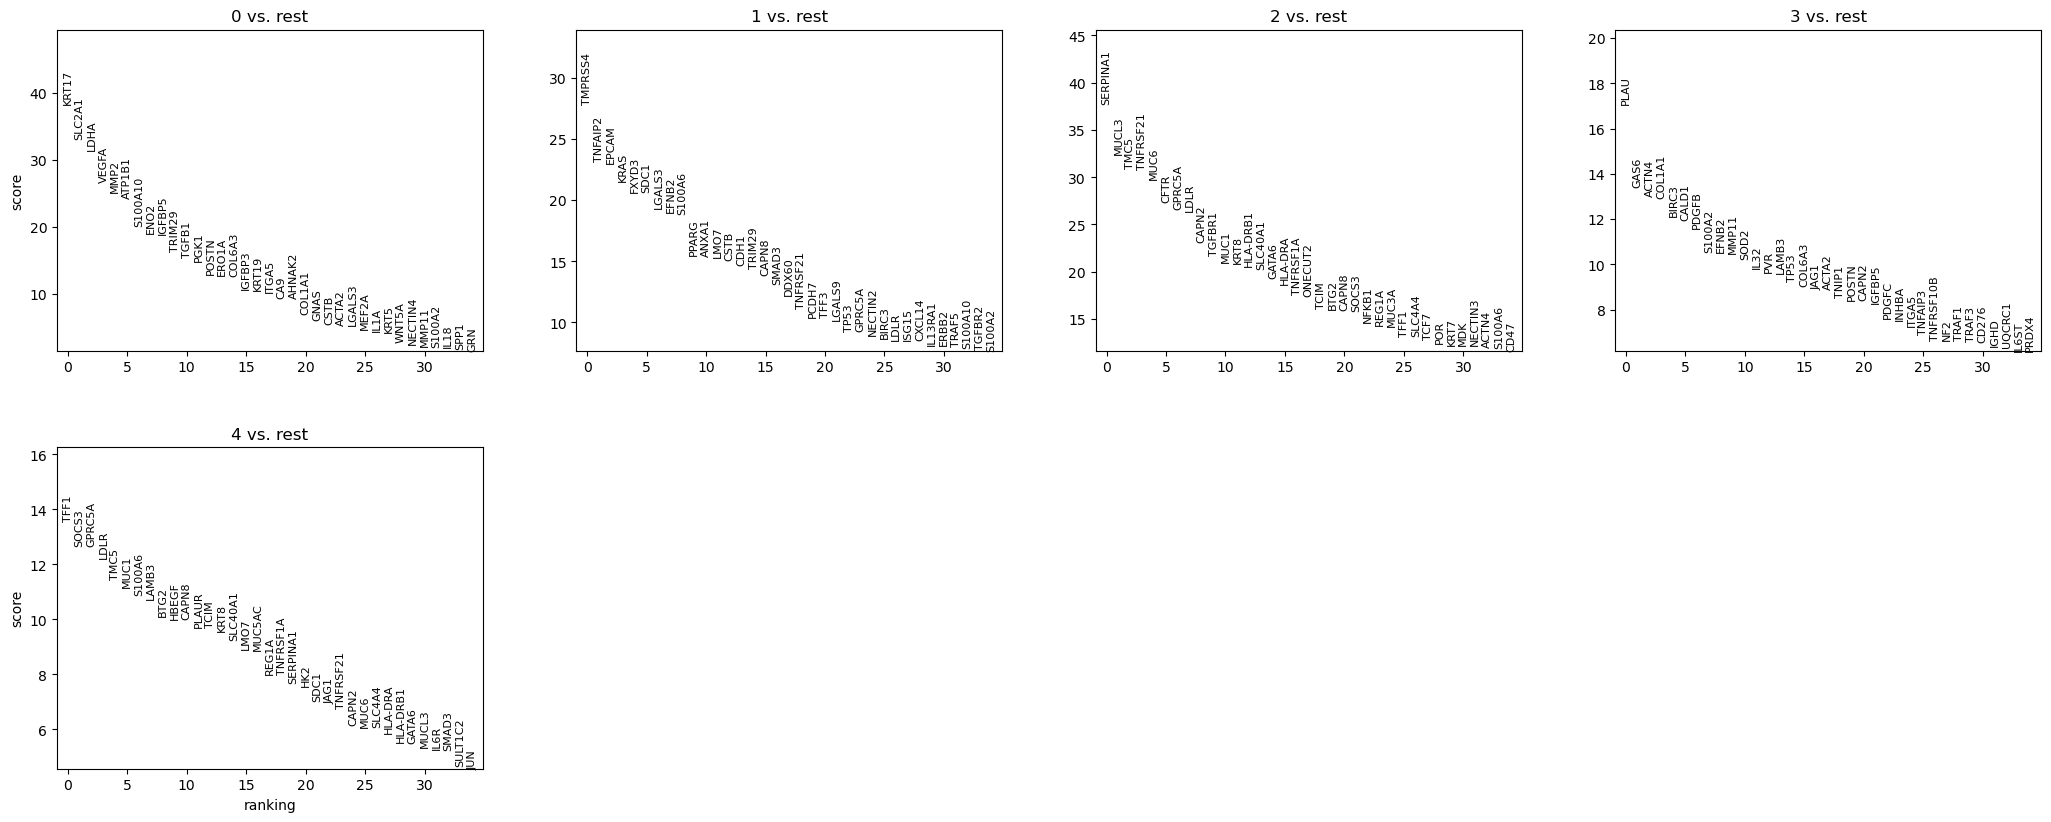

In [34]:
# Find Marker genes
sc.tl.rank_genes_groups(merged, 'leiden_0.5', method='wilcoxon')
sc.pl.rank_genes_groups(merged, n_genes=35, sharey=False)

/homevol/huemail/.local/lib/python3.9/site-packages/squidpy/pl/_spatial_utils.py:483: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = color_source_vector.map(color_map)
/homevol/huemail/.local/lib/python3.9/site-packages/squidpy/pl/_spatial_utils.py:956: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(
/homevol/huemail/.local/lib/python3.9/site-packages/squidpy/pl/_spatial_utils.py:483: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = color_source_vector.map(color_map)
/homevol/huemail/.local/lib/python3.9/site-packa

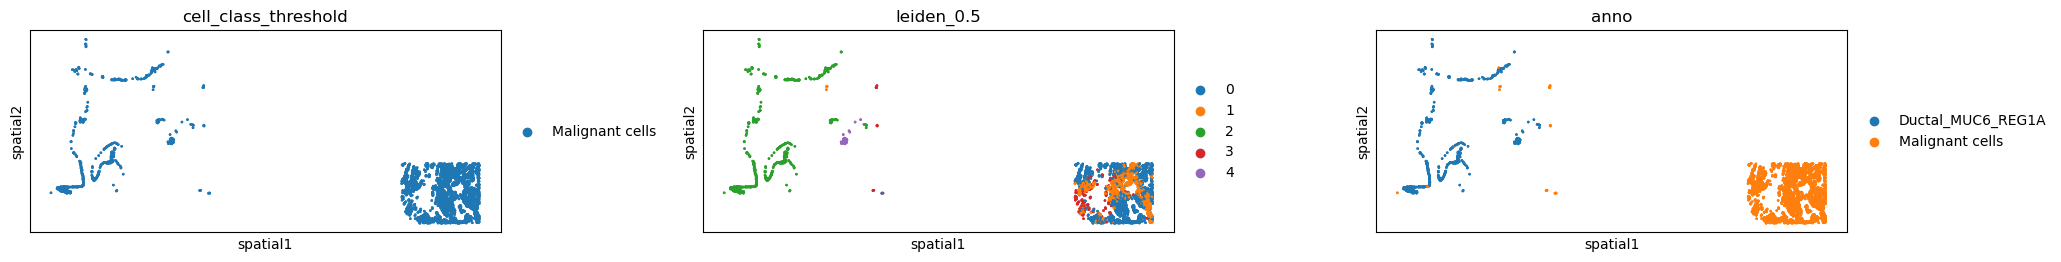

In [35]:
# Visualisation - at spatial context
sq.pl.spatial_scatter(
    merged,
    library_id="spatial",
    shape=None,
    color=['cell_class_threshold','leiden_0.5','anno'],
    wspace=0.3,
    size=3,
    #cmap='RdBu_r',
    # vmin=-2, vmax=2,
    figsize = (6,6)
)

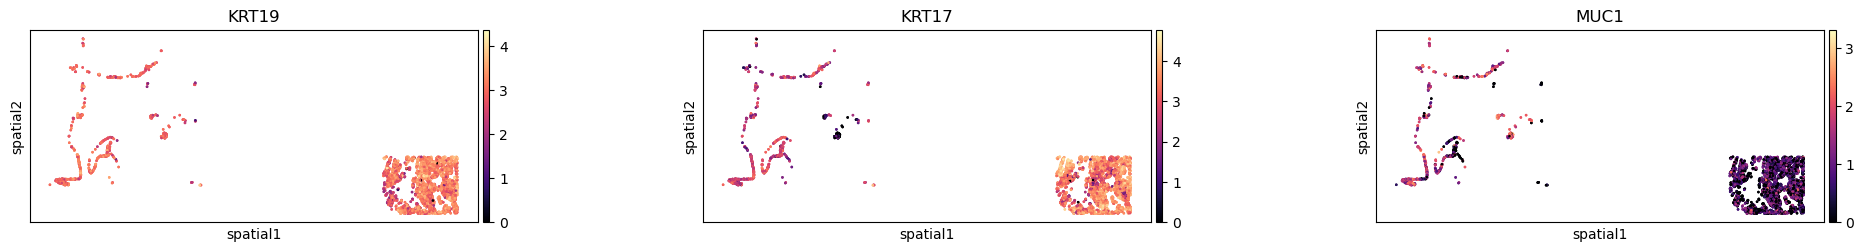

In [69]:
# Visualisation - at spatial context
sq.pl.spatial_scatter(
    merged,
    library_id="spatial",
    shape=None,
    color=['KRT19','KRT17','MUC1'],
    wspace=0.3,
    size=3,
    cmap='magma',
    # vmin=-2, vmax=2,
    figsize = (6,2.5),
    save='MH097_gene_expression.pdf'
)

/homevol/huemail/.local/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1216: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/homevol/huemail/.local/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:391: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/homevol/huemail/.local/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1216: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/homevol/huemail/.l

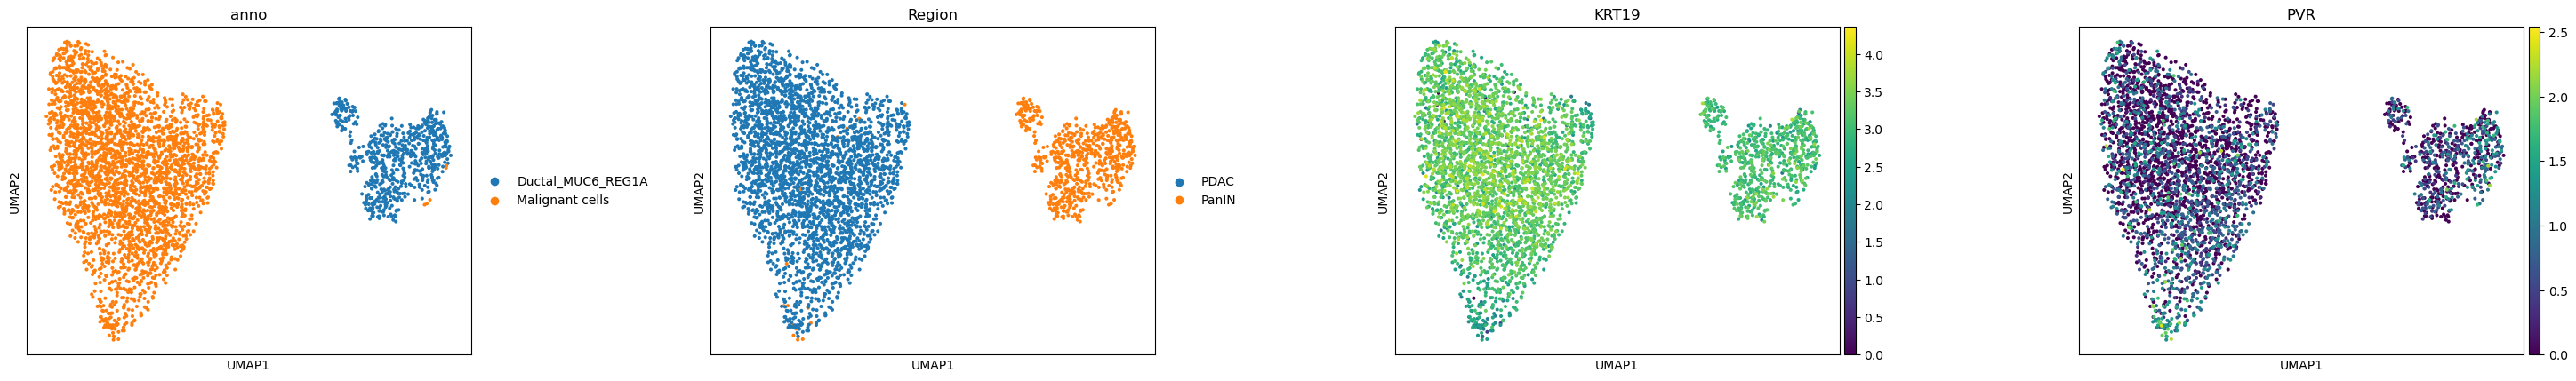

In [41]:
sc.pl.umap(merged, color=['anno','Region','KRT19','PVR'], wspace = 0.4) #,'leiden_1.5','leiden_1.8','PLA2G2A'])#,'leiden_1.5','leiden_2.0', 'leiden_2.5'])

/homevol/huemail/miniconda3/envs/xenium.squidpy/lib/python3.9/site-packages/numpy/core/fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


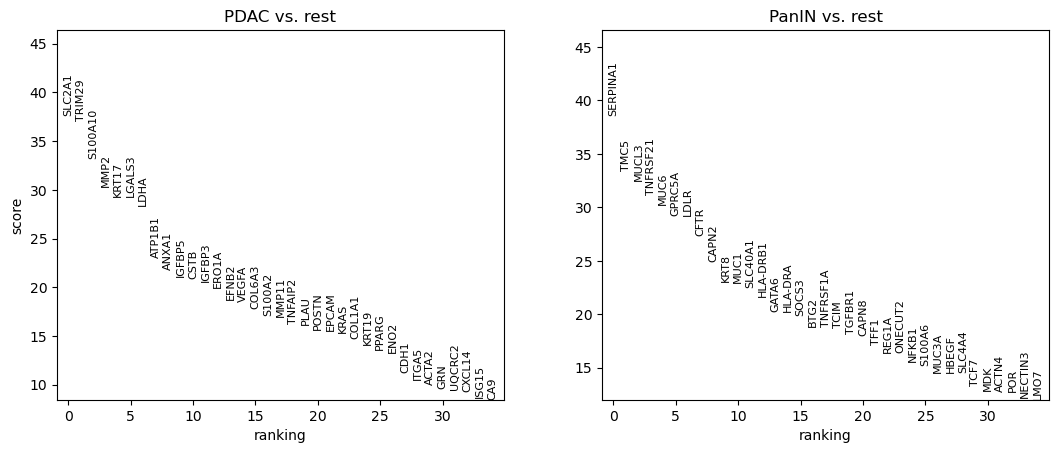

In [42]:
# Find Marker genes
sc.tl.rank_genes_groups(merged, 'Region', method='wilcoxon')
sc.pl.rank_genes_groups(merged, n_genes=35, sharey=False)

/homevol/huemail/.local/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1216: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/homevol/huemail/.local/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:391: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


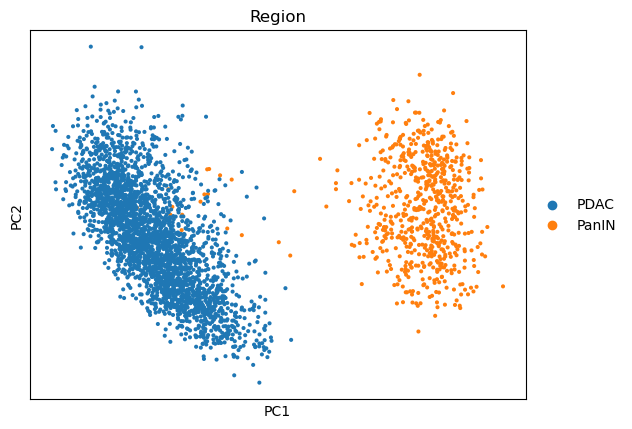

In [43]:
sc.pl.pca(merged, color="Region")

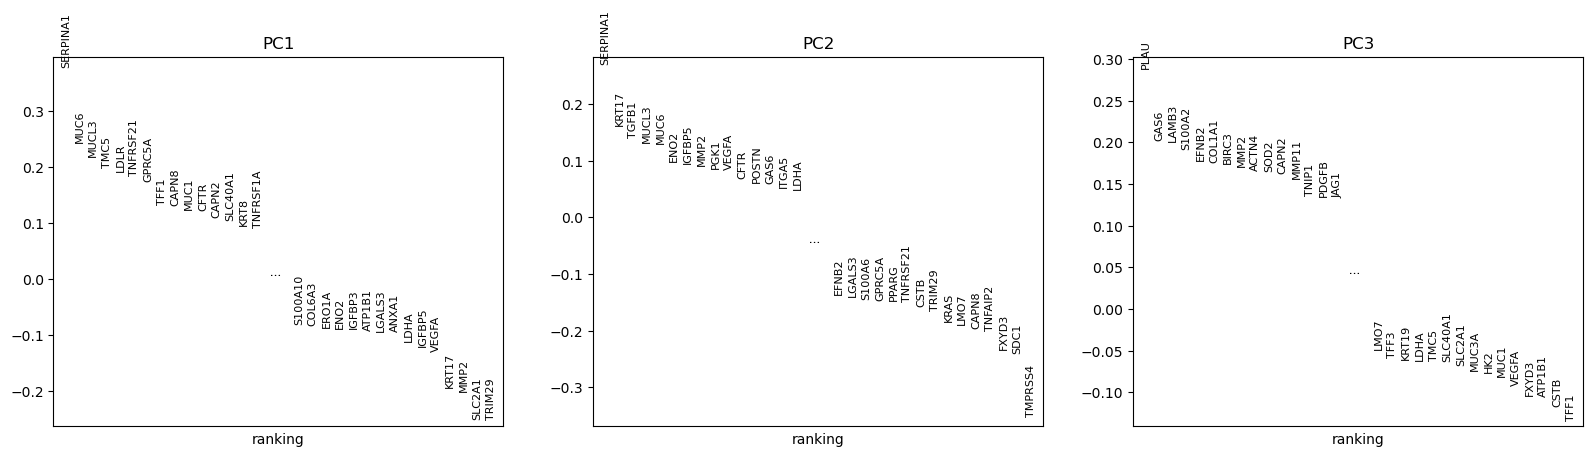

In [44]:
sc.pl.pca_loadings(merged)

In [45]:
pd.DataFrame(merged.uns['rank_genes_groups']['names']).head(10) #wilcox-rank sum

,PDAC,PanIN
0,SLC2A1,SERPINA1
1,TRIM29,TMC5
2,S100A10,MUCL3
3,MMP2,TNFRSF21
4,KRT17,MUC6
5,LGALS3,GPRC5A
6,LDHA,LDLR
7,ATP1B1,CFTR
8,ANXA1,CAPN2
9,IGFBP5,KRT8


In [47]:
features = ['TRIM29','SLC2A1','S100A10','KRT17','LDHA','ATP1B1','ERO1A','VEGFA','EFNB2','KRT19','KRAS','PPARG','ENO2',
            'MUC6','TMC5','TNFRSF21','MUCL3','GATA6','CAPN2','MUC1','TGFBR1','TFF1','TNFRSF1A','ONECUT2','NFKB1','MUC3A','MDK','IL6ST']

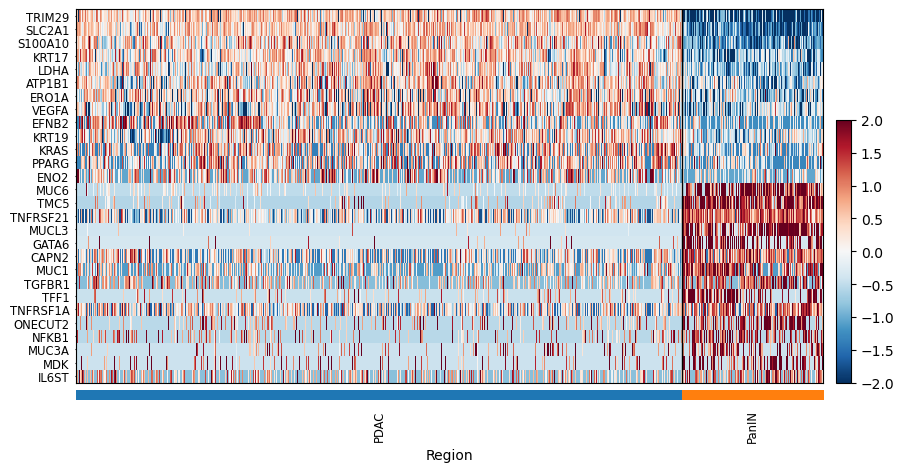

In [48]:
sc.pl.heatmap(
    merged, 
    var_names=features,
    groupby='Region',    # or 'region' or your cluster column
    layer='scaled',  # scale across genes (rows)
    swap_axes=True,
    cmap='RdBu_r',
    vmax = 2,
    vmin = -2,
    save = 'MH097_topDE_PDAC_PanIN.pdf'
)

In [88]:
result = merged.uns['rank_genes_groups']
groups = result['names'].dtype.names
pd.DataFrame(
    {group + '_' + key[:1]: result[key][group]
    for group in groups for key in ['names', 'pvals']}).head(40) 

,PDAC_n,PDAC_p,PanIN_n,PanIN_p
0,SLC2A1,0.000000e+00,SERPINA1,0.000000e+00
1,TRIM29,3.186907e-304,TMC5,6.926105e-242
2,LGALS3,1.972221e-226,MUCL3,1.029569e-230
3,S100A10,1.906492e-216,MUC6,2.997499e-199
4,MMP2,1.992196e-203,TNFRSF21,4.735528e-187
5,KRT17,4.675996e-193,LDLR,3.011943e-177
6,LDHA,1.238198e-187,CFTR,2.051733e-164
7,ATP1B1,8.703761e-143,GPRC5A,1.244017e-160
8,ANXA1,1.483080e-118,CAPN2,2.293398e-119
9,CSTB,3.332601e-109,SLC40A1,1.857690e-110


In [51]:
# Load pathway gene sets (e.g., Wnt, TGF-β)
pathway_gene_sets = {
    #"treatment": ["NRXN3", "SOD3", "CST4", "GYPC","CELA2A","PXDN","CYS1","S100A10"],
    "TNF": ["ABCB1","TRAF1","PIK3CD","TRAF3","CHUK","RIPK1","CASP8","CREB1","TRAF5","TRADD","TNF","TNFRSF1B","MLKL","TNFRSF10B","BIRC2","BIRC3"],
    "TNF_NFKB" : ["CXCL2","CXCL3","IRF1","LAMB3","NFKB1","NFKB2","NFKBIA","SOD2","PLAU","PLAUR","TNFAIP2","TNFAIP3","TNIP1","TRAF1","BTG2","IFIH1"],
    "IFNG" : ["CMPK2","DDX60","GBP4","ICAM1","IDO1","IFIT1","IFIT2","IFIT3","ISG15","OASL","RSAD2","ZBP1"],
    "OXPHOS" : ["NDUFS1","ATP5F1A","ATP1B1","COX5A","UQCRC2","UQCRC1","POR","NDUFV1"],
    "IL6":["IL6","IL6R","IL6ST","STAT3","TNFRSF1A","TNFRSF21","JUN","SOCS3"],#doi: 10.1042/CS20191211
    "HYPOXIA":["VEGFA","LDHA","SLC2A1","ARNT","ERO1A","HIF1A","CA9"], #doi: 10.3390/molecules27165192
    #"WNT": ["WNT6","PTCH1","TCF7","LEF1","AXIN2"],
    "IMMUNESUPRESSION":["IL10","IL2RA","IL1R1","IL13RA1","IL17RA","IL3RA","IL10RA"],
    "SQUAMOUS" : ["KRT5","GATA6","TP63","TRIM29","AHNAK2","GPM6B"],# Bailey et al., 2016
    "TGFB": ["SMAD3","SMAD4","TGFBR1","TGFBR2","ACVR1B","ACVR2A"],#from: https://www.nature.com/articles/s41575-019-0109-y
    #"TIGIT": ["PVR","NECTIN2"]
}

In [52]:
# Recompute gene set scores
for pathway, genes in pathway_gene_sets.items():
    sc.tl.score_genes(
        merged,
        gene_list=genes,
        ctrl_size=20,
        random_state=22,
        score_name=f"{pathway}_pathway_score")

# Store pathway scores in a list
pathway_scores = [f"{pathway}_pathway_score" for pathway in pathway_gene_sets.keys()]
print(pathway_scores)

['TNF_pathway_score', 'TNF_NFKB_pathway_score', 'IFNG_pathway_score', 'OXPHOS_pathway_score', 'IL6_pathway_score', 'HYPOXIA_pathway_score', 'IMMUNESUPRESSION_pathway_score', 'SQUAMOUS_pathway_score', 'TGFB_pathway_score']


/homevol/huemail/miniconda3/envs/xenium.squidpy/lib/python3.9/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
/homevol/huemail/miniconda3/envs/xenium.squidpy/lib/python3.9/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
/homevol/huemail/miniconda3/envs/xenium.squidpy/lib/python3.9/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False 

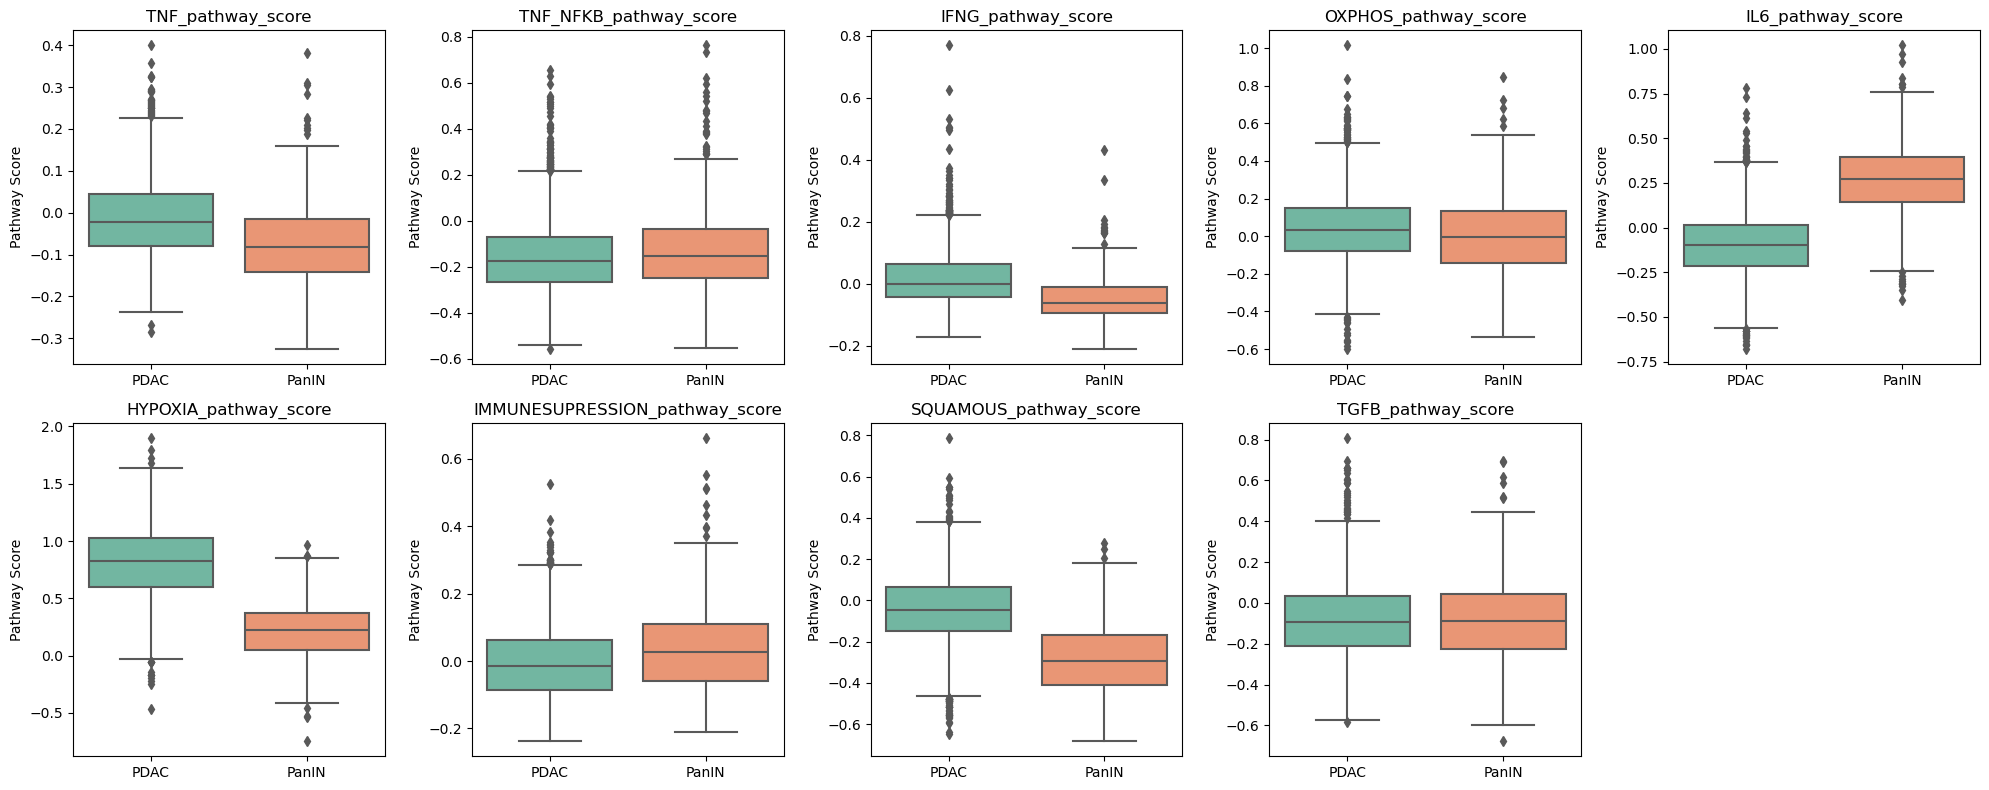

In [53]:
import seaborn as sns
import matplotlib.pyplot as plt
import math

# Number of columns
n_cols = 5
n_rows = math.ceil(len(pathway_scores) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 4), squeeze=False)

for i, pathway in enumerate(pathway_scores):
    row = i // n_cols
    col = i % n_cols
    ax = axes[row][col]

    sns.boxplot(
        x="Region", 
        y=pathway, 
        data=merged.obs, 
        palette="Set2", 
        ax=ax
    )
    ax.set_title(f"{pathway}")
    ax.set_xlabel("")  # Optional: clean up
    ax.set_ylabel("Pathway Score")

# Hide unused axes (if any)
total_plots = len(pathway_scores)
for j in range(total_plots, n_rows * n_cols):
    fig.delaxes(axes[j // n_cols][j % n_cols])

plt.tight_layout()
plt.show()

In [54]:
# z-score normalisation
for key in ['TNF_pathway_score', 'TNF_NFKB_pathway_score', 'IFNG_pathway_score', 'OXPHOS_pathway_score', 'IL6_pathway_score', 'HYPOXIA_pathway_score', 'IMMUNESUPRESSION_pathway_score', 'SQUAMOUS_pathway_score', 'TGFB_pathway_score']:
    vals = merged.obs[key]
    merged.obs[key + "_z"] = (vals - vals.mean()) / vals.std()

In [55]:
merged.obs[key + "_z"].sum()  # ≈ 0, but not exactly 0

2.1671553440683056e-13

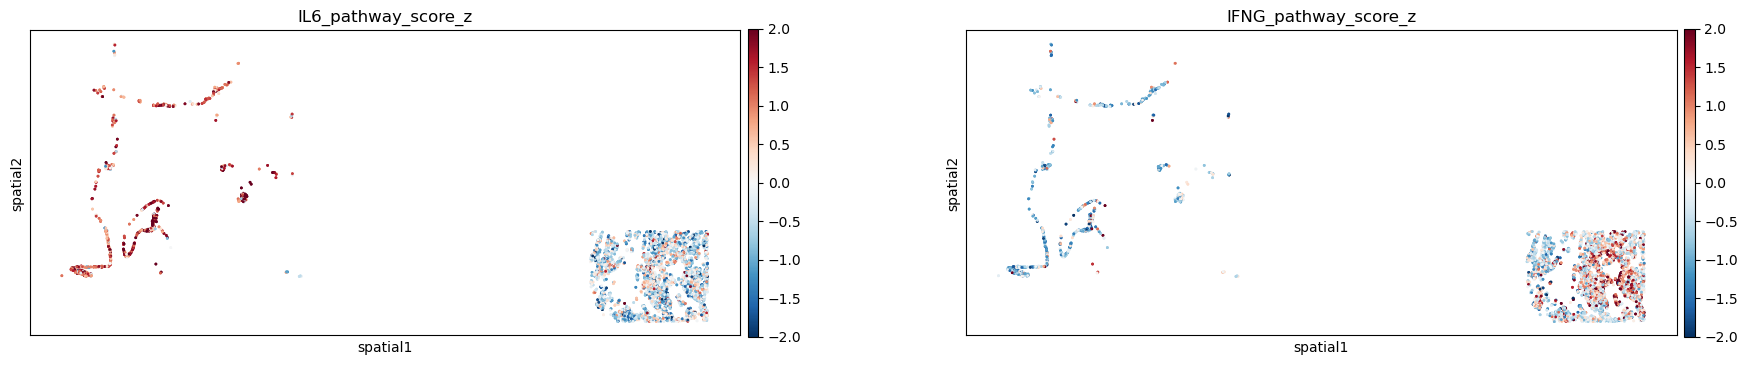

In [56]:
# Visualisation - at spatial context
sq.pl.spatial_scatter(
    merged,
    library_id="spatial",
    shape=None,
    color=['IL6_pathway_score_z', 'IFNG_pathway_score_z'], 
    wspace=0.2,
    size=4,
    cmap='RdBu_r',
     vmin=-2, vmax=2,
    save='Oct25/MH097_PanIN_signalling.pdf',
    figsize = (9,4)
)

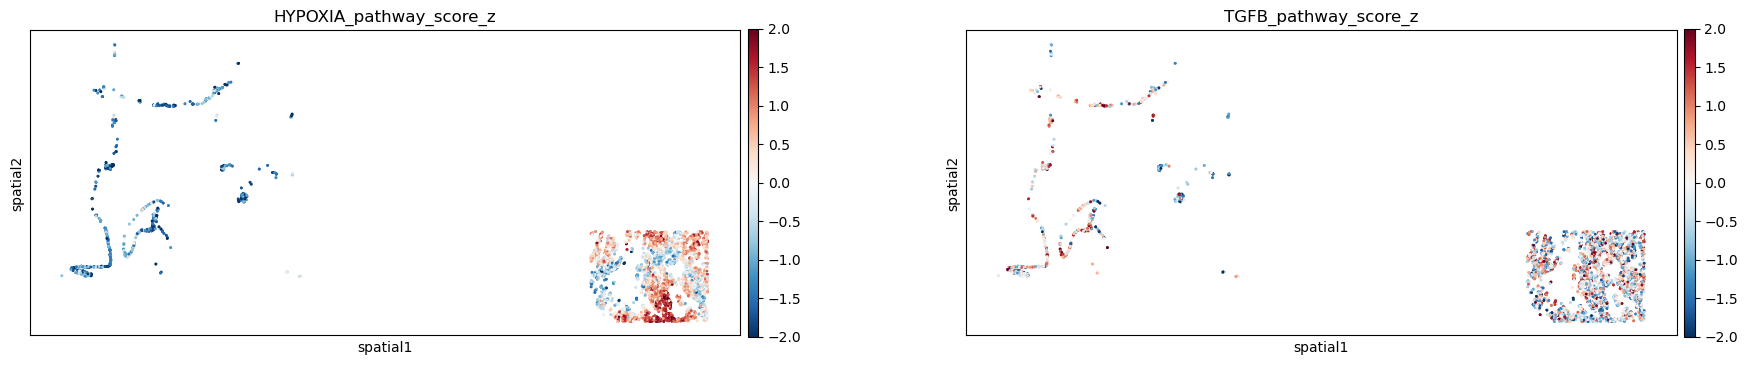

In [57]:
# Visualisation - at spatial context
sq.pl.spatial_scatter(
    merged,
    library_id="spatial",
    shape=None,
    color=['HYPOXIA_pathway_score_z','TGFB_pathway_score_z'
    ],
    wspace=0.2,
    size=4,
    cmap='RdBu_r',
     vmin=-2, vmax=2,
    save='Oct25/MH097_PanIN_signalling_2.pdf',
    figsize = (9,4)
)